In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def parse_log_file(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return pd.DataFrame()
        
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = [p.strip() for p in line.split('|')]
            if len(parts) < 8:
                continue
            
            try:
                model = parts[0].split(':')[1].strip().lower()
                hidden = int(parts[1].split(':')[1].strip())
                seq = int(parts[3].split(':')[1].strip())
                
                # Time parsing
                time_part = parts[6].split(':')[1].strip().replace('s', '')
                if '+-' in time_part:
                    time_mean = float(time_part.split('+-')[0].strip())
                    time_std = float(time_part.split('+-')[1].strip())
                else:
                    time_mean = float(time_part)
                    time_std = 0.0
                
                # VRAM parsing
                vram_part = parts[7].split(':')[1].strip().replace('MB', '')
                if '+-' in vram_part:
                    vram_mean = float(vram_part.split('+-')[0].strip())
                    vram_std = float(vram_part.split('+-')[1].strip())
                else:
                    vram_mean = float(vram_part)
                    vram_std = 0.0
                
                data.append({
                    'Model': model,
                    'Hidden': hidden,
                    'Seq': seq,
                    'Time': time_mean,
                    'Time_std': time_std,
                    'VRAM': vram_mean,
                    'VRAM_std': vram_std
                })
            except Exception as e:
                print(f"Error parsing line: {line}\nException: {e}")
                continue
                
    return pd.DataFrame(data)


def plot_benchmark(hidden_size, metric="time"):
    metric = metric.lower()
    
    # Parse log files
    df_rollout = parse_log_file("./rollout_time.txt")
    df_update = parse_log_file("./update_time.txt")
    
    # Filter by hidden size
    if not df_rollout.empty:
        df_rollout = df_rollout[df_rollout['Hidden'] == hidden_size].copy()
    if not df_update.empty:
        df_update = df_update[df_update['Hidden'] == hidden_size].copy()
        
    if df_rollout.empty and df_update.empty:
        print(f"No data found for hidden size '{hidden_size}' in both files.")
        return
        
    # Set plot theme
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)
    
    # Create 1x2 subplots with independent y-axis scales
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Set metric column and label
    if metric == "time":
        y_col, y_err_col = 'Time', 'Time_std'
        y_label = "Time (ms)"
    elif metric == "vram":
        y_col, y_err_col = 'VRAM', 'VRAM_std'
        y_label = "Peak VRAM (GB)"
    else:
        raise ValueError("Metric must be 'time' or 'vram'")
        
    custom_palette = {
        "mate": "#d62728",   # Red
        "gpt": "#2ca02c",    # Green
        "lstm": "#1f77b4",   # Blue
    }
    
    # Configurations for rollout and update subplots
    plot_configs = [
        (axes[0], df_rollout),
        (axes[1], df_update)
    ]
    
    for ax, df in plot_configs:
        if df.empty:
            continue
            
        models = sorted(df['Model'].unique())
        
        for m in models:
            subset = df[df['Model'] == m].sort_values(by='Seq')
            base_color = custom_palette.get(m, "#000000")
            
            if metric == "time":
                subset[y_col] = subset[y_col] * 1000  # Convert to ms
                subset[y_err_col] = subset[y_err_col] * 1000
            elif metric == "vram":
                subset[y_col] = subset[y_col] / 1024  # Convert to GB
                subset[y_err_col] = subset[y_err_col] / 1024
            
            # Plot mean line
            ax.plot(subset['Seq'], subset[y_col], marker='o', linewidth=6, markersize=12, color=base_color)
            
            # Plot standard deviation as a shaded region
            ax.fill_between(subset['Seq'], 
                            subset[y_col] - subset[y_err_col], 
                            subset[y_col] + subset[y_err_col], 
                            color=base_color, alpha=0.2)
                            
        # Set x-axis properties
        ax.set_xlabel("Episode Length", fontsize=34, labelpad=10)
        ax.tick_params(axis='both', labelsize=30)
        ax.grid(True, linestyle='--', alpha=0.6)

    # Set y-axis label only on the left subplot
    axes[0].set_ylabel(y_label, fontsize=34, labelpad=10)
    
    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()

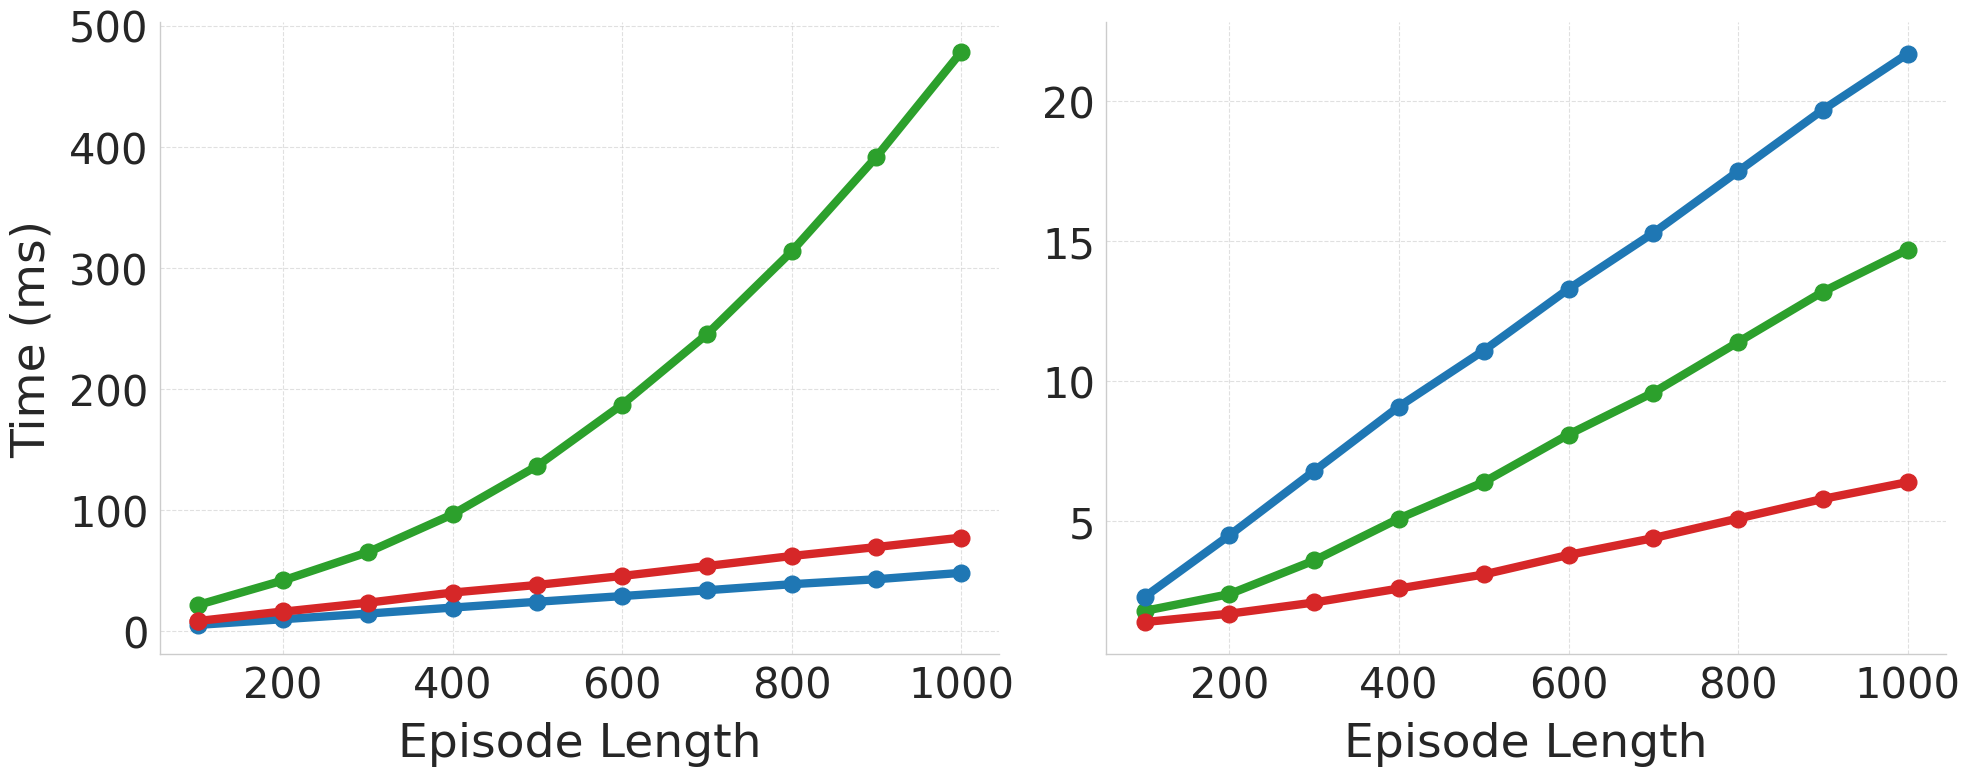

In [3]:
# Compare models at hidden_size=256 left subplot: rollout time, right subplot: update time
plot_benchmark(hidden_size=256, metric="time")

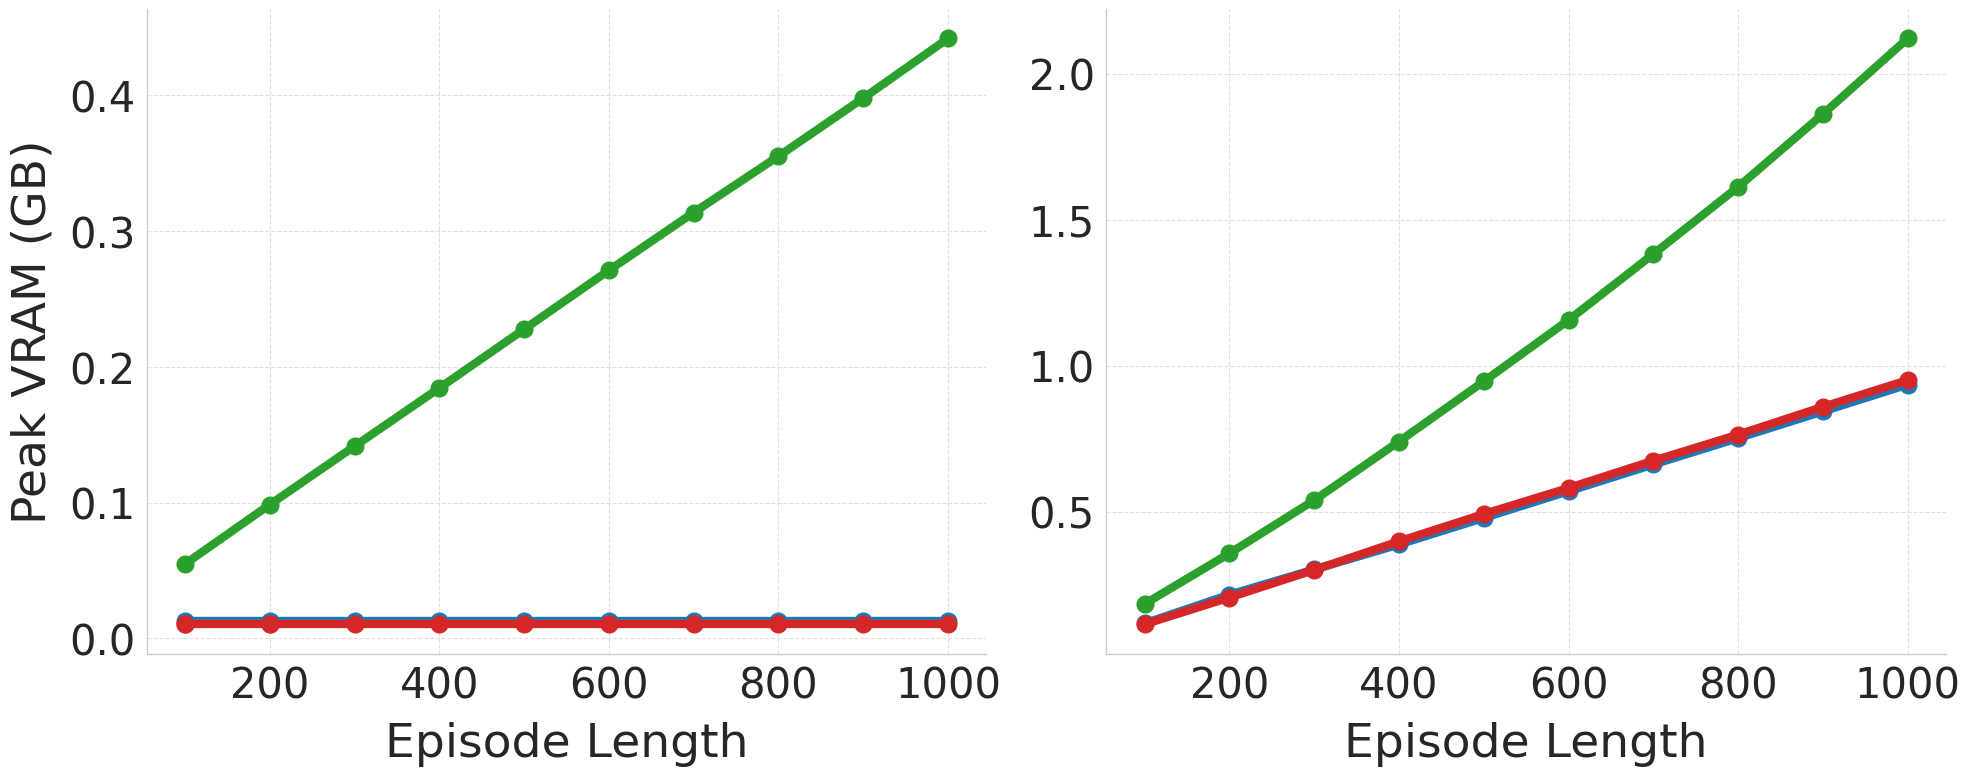

In [4]:
# Compare models at hidden_size=256 left subplot: rollout peak vram, right subplot: update peak vram
plot_benchmark(hidden_size=256, metric="vram")